[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter0_seminar_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 0: Refresher and inference for dependent data

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 0; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 0 (`acov_all`, `lrv`, `nw_rule`, `andrews_bw`, `ewc_lrv`, `fixed_b_table`, `mean_inference`, `politis_white`, `mbb_means`, `sb_indices`, `ols_hac`, `reality_check`) and the seminar functions `simulate_ar1`, `size_table`, `simulate_garch`, `b1_sp500`, `b3_size`, `b5_spurious`.

In [ ]:
from scipy import stats
SEED = 2026
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP_RO = ('prc_hicp_minr', 'M.RCH_A.TOTAL.RO')
START_MACRO = '2000-01-01'
START_INFL = '2006-01-01'
TARGET_START = '2013-01-01'
TARGET = 2.5
H_TS = 4
FIXED_B_GRID = (0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
MA_LENGTHS = (5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250)
SB_MEAN_BLOCK = 10
NUM = {}
A2_DATA = (2.1, 1.4, 0.3, -0.5, 0.2, 1.1, 1.8, 0.9, -0.2, 0.4)
A3_DATA = (1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 2.0, -2.0)
A5_DATA = (1.0, 3.0, 2.0, 6.0, 4.0, 2.0)
A8_PVALUES = (0.001, 0.008, 0.012, 0.03, 0.041, 0.24)
GARCH = (0.02, 0.1, 0.88)
R = {}


def ro_gdp_growth(start=START_MACRO):
    """Quarter-on-quarter growth of Romanian real GDP, in % (100 x log difference)."""
    y = read_eurostat(*GDP_RO)
    return (100 * np.log(y).diff()).dropna().loc[start:].rename('RO GDP growth')


def ro_inflation(start=START_INFL):
    """Romanian HICP inflation, annual rate of change in % (monthly observations)."""
    return read_eurostat(*HICP_RO).loc[start:].rename('RO HICP inflation')


def daily_series():
    """Daily log returns in % of the S&P 500, the BET and EUR/RON (BNR reference rate); squared S&P 500 returns."""
    sp = log_returns('sp500')
    return {'S&P 500 returns': sp, 'S&P 500 squared returns': (sp ** 2).rename('sq'),
            'BET returns': log_returns('bet'), 'EUR/RON returns': log_returns('eurron')}


def term_spread_data(h=H_TS):
    """US quarterly data: annualised real GDP growth over the next h quarters and the 10-year minus 3-month spread."""
    f = read_fred(['GS10', 'TB3MS'])
    spread = (f['GS10'] - f['TB3MS']).resample('QS').mean()
    gdp = read_fred('GDPC1')
    growth = (400 / h) * np.log(gdp.shift(-h) / gdp)
    d = pd.concat([growth.rename('growth'), spread.rename('spread')], axis=1).dropna()
    return d.loc['1962-01-01':]


def save(name, save_it=True):
    """Save the current figure in charts/ (or show it in a notebook)."""
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def acov_all(x):
    """Sample autocovariances gamma_0, ..., gamma_{T-1} (divisor T, demeaned), by FFT."""
    x = np.asarray(x, float)
    x = x - x.mean(axis=-1, keepdims=True)
    T = x.shape[-1]
    f = np.fft.rfft(x, 2 * T, axis=-1)
    return np.fft.irfft(f * np.conj(f), axis=-1)[..., :T] / T


def kernel(x, kind='bartlett'):
    """Kernel weights k(x): Bartlett (Newey-West), Parzen, quadratic spectral (QS), truncated."""
    x = np.abs(np.asarray(x, float))
    if kind == 'bartlett':
        return np.where(x <= 1, 1 - x, 0.0)
    if kind == 'parzen':
        return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))
    if kind == 'qs':
        z = 6 * np.pi * np.where(x == 0, 1.0, x) / 5
        w = 25 / (12 * np.pi ** 2 * np.where(x == 0, 1.0, x) ** 2) * (np.sin(z) / z - np.cos(z))
        return np.where(x == 0, 1.0, w)
    if kind == 'truncated':
        return np.where(x <= 1, 1.0, 0.0)
    raise ValueError(kind)


def lrv(u, S, kind='bartlett'):
    """Kernel estimator of the long-run variance: gamma_0 + 2 sum_j k(j/S) gamma_j (works on rows of a matrix)."""
    g = acov_all(u)
    T = g.shape[-1]
    j = np.arange(1, T)
    return g[..., 0] + 2 * (g[..., 1:] * kernel(j / S, kind)).sum(axis=-1)


def nw_rule(T):
    """Newey-West (1994) rule of thumb: L = floor(4 (T/100)^(2/9)) lags, i.e. Bartlett bandwidth S = L + 1."""
    return int(np.floor(4 * (T / 100) ** (2 / 9))) + 1


def ar1_coef(u):
    """OLS AR(1) coefficient of the demeaned series (rows of a matrix)."""
    u = np.asarray(u, float)
    u = u - u.mean(axis=-1, keepdims=True)
    return (u[..., 1:] * u[..., :-1]).sum(axis=-1) / (u[..., :-1] ** 2).sum(axis=-1)


def andrews_bw(u, kind='bartlett'):
    """Andrews (1991) AR(1) plug-in bandwidth: 1.1447 (a1 T)^(1/3) Bartlett; 2.6614 / 1.3221 (a2 T)^(1/5) Parzen / QS."""
    u = np.asarray(u, float)
    T = u.shape[-1]
    r = ar1_coef(u)
    if kind == 'bartlett':
        a1 = 4 * r ** 2 / ((1 - r) ** 2 * (1 + r) ** 2)
        S = 1.1447 * (a1 * T) ** (1 / 3)
    else:
        a2 = 4 * r ** 2 / (1 - r) ** 4
        S = (2.6614 if kind == 'parzen' else 1.3221) * (a2 * T) ** (1 / 5)
    return np.clip(S, 1.0, T)


def llsw_bw(T):
    """Lazarus, Lewis, Stock and Watson (2018): Newey-West bandwidth S = 1.3 sqrt(T), used with fixed-b critical values."""
    return 1.3 * np.sqrt(T)


def ewc_nu(T):
    """Lazarus, Lewis, Stock and Watson (2018): number of cosine terms (degrees of freedom) of the EWC estimator, 0.4 T^(2/3)."""
    return max(1, int(round(0.4 * T ** (2 / 3))))


def ewc_lrv(u, nu):
    """Equal-weighted cosine (EWC) estimator: the average of nu squared cosine projections of the demeaned series."""
    u = np.asarray(u, float)
    u = u - u.mean(axis=-1, keepdims=True)
    T = u.shape[-1]
    t = np.arange(1, T + 1)
    C = np.sqrt(2 / T) * np.cos(np.pi * np.outer(np.arange(1, nu + 1), t - 0.5) / T)   # nu x T
    lam = u @ C.T
    return (lam ** 2).mean(axis=-1)


def fixed_b_table(grid=FIXED_B_GRID, kind='bartlett', n=500, reps=20000, alpha=0.05, seed=SEED):
    """Fixed-b critical values (Kiefer and Vogelsang 2005) of the two-sided t-test for a mean, by simulation:
    the (1 - alpha) quantile of |t| when S = b T, i.i.d. N(0, 1) data of length n (approximates the limit)."""
    rng = np.random.default_rng(seed)
    j = np.arange(1, n)
    W = np.array([kernel(j / (b * n), kind) for b in grid])        # len(grid) x (n - 1)
    tabs = []
    for _ in range(reps // 5000):                                  # in chunks of 5000 replications
        x = rng.standard_normal((5000, n))
        g = acov_all(x)
        v = g[:, :1] + 2 * g[:, 1:] @ W.T                          # 5000 x len(grid)
        tabs.append(np.abs(np.sqrt(n) * x.mean(axis=1))[:, None] / np.sqrt(np.maximum(v, 1e-12)))
    t = np.vstack(tabs)
    return {b: float(np.quantile(t[:, i], 1 - alpha)) for i, b in enumerate(grid)}


def fixed_b_cv(b, table):
    """Fixed-b critical value at b, by linear interpolation in the simulated table (1.96 at b = 0)."""
    bs = np.array([0.0] + sorted(table))
    cv = np.array([stats.norm.ppf(0.975)] + [table[k] for k in sorted(table)])
    return float(np.interp(b, bs, cv))


def mean_inference(x, cvtab, mu0=0.0):
    """Standard errors of a sample mean and t-statistics for H0: mu = mu0, by method."""
    x = np.asarray(x, float)
    T = len(x)
    m = x.mean()
    g0 = acov_all(x)[0]
    S_nw, S_and, S_qs, S_ll, nu = nw_rule(T), float(andrews_bw(x)), float(andrews_bw(x, 'qs')), llsw_bw(T), ewc_nu(T)
    out = {'T': T, 'mean': m, 'rho1': float(ar1_coef(x)), 'S_nw': S_nw, 'S_and': S_and, 'S_qs': S_qs, 'S_ll': S_ll, 'nu': nu}
    v = {'naive': g0, 'nw': lrv(x, S_nw), 'andrews': lrv(x, S_and), 'qs': lrv(x, S_qs, 'qs'), 'llsw': lrv(x, S_ll),
         'ewc': ewc_lrv(x, nu)}
    cv = {'naive': 1.96, 'nw': 1.96, 'andrews': 1.96, 'qs': 1.96, 'llsw': fixed_b_cv(S_ll / T, cvtab),
          'ewc': float(stats.t.ppf(0.975, nu))}
    for k in v:
        se = float(np.sqrt(max(v[k], 1e-300) / T))
        out[f'se_{k}'] = se
        out[f't_{k}'] = (m - mu0) / se
        out[f'cv_{k}'] = cv[k]
        out[f'lo_{k}'], out[f'hi_{k}'] = m - cv[k] * se, m + cv[k] * se
    return out


def politis_white(x):
    """Automatic block length of Politis and White (2004) with the correction of Patton, Politis and White (2009):
    returns (b_SB, b_CB), the optimal mean block lengths of the stationary and of the circular block bootstrap."""
    x = np.asarray(x, float)
    n = len(x)
    g = acov_all(x)
    rho = g / g[0]
    kn = max(5, int(np.ceil(np.sqrt(np.log10(n)))))
    mmax = int(np.ceil(np.sqrt(n))) + kn
    bmax = int(np.ceil(min(3 * np.sqrt(n), n / 3)))
    c = 2 * np.sqrt(np.log10(n) / n)
    mhat = None
    for m in range(1, mmax + 1):
        if np.all(np.abs(rho[m:m + kn]) < c):
            mhat = m
            break
    if mhat is None:
        mhat = mmax
    M = min(2 * mhat, mmax)
    k = np.arange(-M, M + 1)
    lam = np.where(np.abs(k / M) <= 0.5, 1.0, np.where(np.abs(k / M) <= 1, 2 * (1 - np.abs(k / M)), 0.0))
    gk = g[np.abs(k)]
    G = np.sum(lam * np.abs(k) * gk)
    g0 = np.sum(lam * gk)
    b_sb = (2 * G ** 2 / (2 * g0 ** 2)) ** (1 / 3) * n ** (1 / 3)
    b_cb = (2 * G ** 2 / (4 / 3 * g0 ** 2)) ** (1 / 3) * n ** (1 / 3)
    return float(min(b_sb, bmax)), float(min(b_cb, bmax))


def mbb_means(x, l, B, rng, circular=False):
    """Bootstrap means of the moving-block (Kunsch 1989) or circular (Politis and Romano 1992) block bootstrap:
    k = ceil(T / l) blocks of length l drawn with replacement; the first T values are kept."""
    x = np.asarray(x, float)
    T = len(x)
    l = int(max(1, round(l)))
    k = int(np.ceil(T / l))
    xx = np.concatenate([x, x[:l - 1]]) if circular else x
    nblocks = T if circular else T - l + 1
    starts = rng.integers(0, nblocks, size=(B, k))
    idx = (starts[:, :, None] + np.arange(l)[None, None, :]).reshape(B, -1)[:, :T]
    return xx[idx].mean(axis=1)


def sb_means(x, b, B, rng):
    """Bootstrap means of the stationary bootstrap (Politis and Romano 1994): blocks with geometric lengths of
    mean b, starting at uniform positions, wrapped around the end of the sample."""
    x = np.asarray(x, float)
    T = len(x)
    p = 1 / b
    out = np.empty(B)
    for i in range(B):
        idx = np.empty(T, dtype=int)
        idx[0] = rng.integers(T)
        new = rng.random(T) < p
        jumps = rng.integers(0, T, size=T)
        for t in range(1, T):
            idx[t] = jumps[t] if new[t] else (idx[t - 1] + 1) % T
        out[i] = x[idx].mean()
    return out


def sb_indices(T, b, B, rng):
    """Index matrix (B x T) of the stationary bootstrap, vectorised over replications."""
    p = 1 / b
    idx = np.empty((B, T), dtype=int)
    idx[:, 0] = rng.integers(0, T, size=B)
    new = rng.random((B, T)) < p
    jumps = rng.integers(0, T, size=(B, T))
    for t in range(1, T):
        idx[:, t] = np.where(new[:, t], jumps[:, t], (idx[:, t - 1] + 1) % T)
    return idx


def iid_means(x, B, rng):
    """Bootstrap means of the i.i.d. (Efron) bootstrap."""
    x = np.asarray(x, float)
    return x[rng.integers(0, len(x), size=(B, len(x)))].mean(axis=1)


def ols_hac(y, X, S=None, kind='bartlett'):
    """OLS with the sandwich covariance (X'X)^-1 T Omega (X'X)^-1; Omega the kernel long-run variance of x_t u_t."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T = len(y)
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    u = y - X @ beta
    h = X * u[:, None]
    if S is None:
        Om = h.T @ h / T
    else:
        Om = h.T @ h / T
        for j in range(1, T):
            w = kernel(j / S, kind)
            if w == 0 and kind != 'qs':
                break
            G = h[j:].T @ h[:-j] / T
            Om += w * (G + G.T)
    V = T * XtX_inv @ Om @ XtX_inv
    return beta, np.sqrt(np.diag(V)), u


def ma_rule_returns(price, lengths=MA_LENGTHS):
    """Excess daily log returns (%) of the moving-average rules over buy-and-hold: the rule is in the index on day t
    if the close of day t-1 is above its n-day moving average, otherwise out of the market (zero return), so
    f_t = (s_{t-1} - 1) r_t; no transaction costs."""
    r = 100 * np.log(price).diff()
    out = {}
    for n in lengths:
        sig = (price > price.rolling(n).mean()).astype(float).shift(1)
        out[n] = (sig - 1) * r
    df = pd.DataFrame(out).iloc[max(lengths) + 1:].dropna()
    return df


def reality_check(f, B=999, mean_block=SB_MEAN_BLOCK, seed=SEED):
    """White (2000) Reality Check: V = max_k sqrt(n) mean(f_k); bootstrap V* = max_k sqrt(n) (mean(f*_k) - mean(f_k))
    with the stationary bootstrap; p-value = share of V* above V. Also the naive p-value of the best rule alone."""
    rng = np.random.default_rng(seed)
    F = np.asarray(f, float)
    n = F.shape[0]
    fbar = F.mean(axis=0)
    V = np.sqrt(n) * fbar.max()
    idx = sb_indices(n, mean_block, B, rng)
    Vs = np.empty(B)
    for i in range(B):
        Vs[i] = np.sqrt(n) * (F[idx[i]].mean(axis=0) - fbar).max()
    kbest = int(np.argmax(fbar))
    x = F[:, kbest]
    se = np.sqrt(lrv(x, nw_rule(n)) / n)
    return {'V': float(V), 'p_rc': float((Vs > V).mean()), 'best': kbest, 'best_mean': float(fbar[kbest]),
            't_best': float(fbar[kbest] / se), 'p_naive': float(1 - stats.norm.cdf(fbar[kbest] / se)), 'n': n,
            'K': F.shape[1], 'n_sig': int((fbar / np.sqrt(lrv(F.T, nw_rule(n)) / n) > 1.645).sum()), 'Vs': Vs}


def mc_size(phi, T, cvtab, reps=5000, B=399, breps=1000, seed=SEED):
    """Rejection rates at 5% of H0: mu = 0 for an AR(1) with N(0, 1) innovations, by method."""
    rng = np.random.default_rng(seed + int(1000 * phi) + T)
    e = rng.standard_normal((reps, T + 200))
    x = np.zeros_like(e)
    for t in range(1, e.shape[1]):
        x[:, t] = phi * x[:, t - 1] + e[:, t]
    x = x[:, 200:]
    m = x.mean(axis=1)
    g = acov_all(x)
    j = np.arange(1, T)
    t_of = lambda v: np.abs(np.sqrt(T) * m / np.sqrt(np.maximum(v, 1e-12)))
    S_nw = nw_rule(T)
    S_and = andrews_bw(x)
    S_qs = andrews_bw(x, 'qs')
    S_ll = llsw_bw(T)
    nu = ewc_nu(T)
    v_nw = g[:, 0] + 2 * (g[:, 1:] * kernel(j / S_nw)).sum(axis=1)
    v_and = g[:, 0] + 2 * (g[:, 1:] * kernel(j[None, :] / S_and[:, None])).sum(axis=1)
    v_qs = g[:, 0] + 2 * (g[:, 1:] * kernel(j[None, :] / S_qs[:, None], 'qs')).sum(axis=1)
    v_ll = g[:, 0] + 2 * (g[:, 1:] * kernel(j / S_ll)).sum(axis=1)
    out = {'naive': float((t_of(g[:, 0]) > 1.96).mean()), 'nw': float((t_of(v_nw) > 1.96).mean()),
           'andrews': float((t_of(v_and) > 1.96).mean()), 'qs': float((t_of(v_qs) > 1.96).mean()),
           'llsw': float((t_of(v_ll) > fixed_b_cv(S_ll / T, cvtab)).mean()),
           'ewc': float((t_of(ewc_lrv(x, nu)) > stats.t.ppf(0.975, nu)).mean())}
    rej = []
    for i in range(breps):
        b_sb, b_cb = politis_white(x[i])
        bm = mbb_means(x[i], b_cb, B, rng, circular=True)
        rej.append(abs(m[i]) > np.quantile(np.abs(bm - bm.mean()), 0.95))
    out['cbb'] = float(np.mean(rej))
    return out


def simulate_ar1(phi, T, reps, rng, burn=200):
    """reps x T matrix of AR(1) paths with N(0, 1) innovations."""
    e = rng.standard_normal((reps, T + burn))
    x = np.zeros_like(e)
    for t in range(1, T + burn):
        x[:, t] = phi * x[:, t - 1] + e[:, t]
    return x[:, burn:]


def size_table(x, mu0, cvtab):
    """Rejection rates at 5% of H0: mean = mu0 for each row of x: naive, Newey-West rule, NW fixed-b, EWC."""
    reps, T = x.shape
    m = x.mean(axis=1) - mu0
    g = acov_all(x)
    j = np.arange(1, T)
    S_nw, S_ll, nu = nw_rule(T), llsw_bw(T), ewc_nu(T)
    v = {'naive': g[:, 0], 'nw': g[:, 0] + 2 * (g[:, 1:] * kernel(j / S_nw)).sum(axis=1),
         'llsw': g[:, 0] + 2 * (g[:, 1:] * kernel(j / S_ll)).sum(axis=1), 'ewc': ewc_lrv(x, nu)}
    cv = {'naive': 1.96, 'nw': 1.96, 'llsw': fixed_b_cv(S_ll / T, cvtab), 'ewc': stats.t.ppf(0.975, nu)}
    return {k: float((np.abs(np.sqrt(T) * m / np.sqrt(np.maximum(v[k], 1e-12))) > cv[k]).mean()) for k in v}


def simulate_garch(T, reps, rng, omega=GARCH[0], alpha=GARCH[1], beta=GARCH[2], burn=500):
    """reps x T matrix of GARCH(1,1) returns with N(0, 1) innovations; unconditional variance omega/(1-alpha-beta)."""
    s2 = np.full(reps, omega / (1 - alpha - beta))
    r = np.zeros((reps, T + burn))
    for t in range(T + burn):
        r[:, t] = np.sqrt(s2) * rng.standard_normal(reps)
        s2 = omega + alpha * r[:, t] ** 2 + beta * s2
    return r[:, burn:]


def b1_sp500(save_it=True, cvtab=None):
    """S&P 500 mean daily log return: standard errors by method (the same estimators as the lecture)."""
    cvtab = cvtab or fixed_b_table()
    x = daily_series()['S&P 500 returns']
    r = mean_inference(x.values, cvtab)
    lab = {'naive': 'naive', 'nw': 'NW rule', 'andrews': 'NW Andrews', 'qs': 'QS Andrews', 'llsw': 'NW fixed-b',
           'ewc': 'EWC'}
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.bar(list(lab.values()), [r[f't_{k}'] for k in lab], color=st.MainBlue, label='t-statistic of H0: mean = 0')
    ax.plot(list(lab.values()), [r[f'cv_{k}'] for k in lab], 'o--', color=st.IDAred, label='5% two-sided critical value')
    ax.set_ylabel('t-statistic')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ch0_sem_b1_tstats', save_it)
    r['ann'] = 252 * r['mean']
    r['first'], r['last'] = str(x.index[0].date()), str(x.index[-1].date())
    R['B1'] = r
    return r


def b3_size(save_it=True, cvtab=None, reps=4000):
    """Monte Carlo of size: AR(1) with phi in {0, 0.5, 0.8}, T = 106 (the length of the GDP sample)."""
    cvtab = cvtab or fixed_b_table()
    rng = np.random.default_rng(SEED)
    T = len(ro_gdp_growth())
    phis = (0.0, 0.5, 0.8)
    res = {p: size_table(simulate_ar1(p, T, reps, rng), 0.0, cvtab) for p in phis}
    lab = {'naive': 'naive', 'nw': 'NW rule of thumb', 'llsw': 'NW fixed-b (LLSW)', 'ewc': 'EWC'}
    cols = [st.IDAred, st.Orange, st.MainBlue, st.Forest]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    w = 0.2
    for i, (k, c) in enumerate(zip(lab, cols)):
        ax.bar(np.arange(len(phis)) + (i - 1.5) * w, [res[p][k] for p in phis], width=w, color=c, label=lab[k])
    ax.axhline(0.05, color=st.DarkText, ls=':', lw=1)
    ax.set_xticks(range(len(phis)))
    ax.set_xticklabels([f'phi = {p}' for p in phis])
    ax.set_ylabel('rejection rate under H0')
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    save('ch0_sem_b3_size', save_it)
    R['B3'] = {'T': T, 'reps': reps, 'res': {str(p): res[p] for p in phis}}
    return R['B3']


def b5_spurious(save_it=True, cvtab=None, reps=10000, T=50):
    """Granger and Newbold (1974): regress one random walk on an independent one, T = 50; share of |t| > 2 with
    OLS, Newey-West and fixed-b standard errors; the same regression in first differences."""
    cvtab = cvtab or fixed_b_table()
    rng = np.random.default_rng(SEED)
    out = {}
    tt = {'ols': [], 'nw': [], 'll': [], 'diff': []}
    S_ll = llsw_bw(T)
    for i in range(reps):
        y = np.cumsum(rng.standard_normal(T))
        x = np.cumsum(rng.standard_normal(T))
        X = np.column_stack([np.ones(T), x])
        b, se, u = ols_hac(y, X)
        s2 = u @ u / (T - 2)
        se_c = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
        tt['ols'].append(b[1] / se_c)
        _, se_nw, _ = ols_hac(y, X, S=nw_rule(T))
        tt['nw'].append(b[1] / se_nw[1])
        _, se_ll, _ = ols_hac(y, X, S=S_ll)
        tt['ll'].append(b[1] / se_ll[1])
        Xd = np.column_stack([np.ones(T - 1), np.diff(x)])
        bd, _, ud = ols_hac(np.diff(y), Xd)
        s2d = ud @ ud / (T - 3)
        tt['diff'].append(bd[1] / np.sqrt(s2d * np.linalg.inv(Xd.T @ Xd)[1, 1]))
    tt = {k: np.array(v) for k, v in tt.items()}
    out = {'reps': reps, 'T': T, 'ols': float((np.abs(tt['ols']) > 2).mean()), 'nw': float((np.abs(tt['nw']) > 2).mean()),
           'll': float((np.abs(tt['ll']) > fixed_b_cv(S_ll / T, cvtab)).mean()),
           'diff': float((np.abs(tt['diff']) > 2).mean()), 'first100': float((np.abs(tt['ols'][:100]) > 2).mean()),
           'cv_ll': fixed_b_cv(S_ll / T, cvtab), 'sd_t': float(tt['ols'].std())}
    fig, ax = plt.subplots(figsize=(10, 3.9))
    bins = np.linspace(-15, 15, 81)
    ax.hist(np.clip(tt['ols'], -15, 15), bins=bins, density=True, color=st.Amber, alpha=0.6, label='levels, OLS t')
    ax.hist(np.clip(tt['nw'], -15, 15), bins=bins, density=True, histtype='step', lw=1.8, color=st.MainBlue,
            label='levels, Newey-West t')
    ax.hist(tt['diff'], bins=bins, density=True, histtype='step', lw=1.8, color=st.Forest, label='first differences, OLS t')
    ax.axvline(-2, color=st.IDAred, ls='--', lw=1)
    ax.axvline(2, color=st.IDAred, ls='--', lw=1, label='|t| = 2')
    ax.set_xlabel('t-statistic of the slope (clipped at +/- 15)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.18)
    save('ch0_sem_b5_spurious', save_it)
    R['B5'] = out
    return out

In [ ]:
cvtab = fixed_b_table()   # fixed-b critical values of the Bartlett t-test, used in Part B

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: long-run variances and the naive test

**Context.** AR(1) $x_t = 0.6x_{t-1} + \varepsilon_t$ and MA(1) $y_t = \varepsilon_t + 0.5\varepsilon_{t-1}$, $\sigma^2 = 1$.

1. Compute $\gamma_0$, $\Omega$ and $\Omega/\gamma_0$ for both processes.
2. Compute the asymptotic size of the naive 5% $t$-test for the AR(1) mean.
3. Compute $\Omega/\gamma_0$ for $\phi = -0.6$ and say what happens to the naive test.

**Report:** two ratios, one size, one sentence.

In [8]:
# Solution
phi, theta = 0.6, 0.5
print('AR(1): g0 =', 1 / (1 - phi**2), ' Omega =', 1 / (1 - phi)**2, ' ratio =', (1 + phi) / (1 - phi))
print('MA(1): g0 =', 1 + theta**2, ' Omega =', (1 + theta)**2, ' ratio =', (1 + theta)**2 / (1 + theta**2))
print('size of the naive test:', 2 * (1 - stats.norm.cdf(1.96 / np.sqrt((1 + phi) / (1 - phi)))))
print('ratio at phi = -0.6:', (1 - 0.6) / (1 + 0.6))

AR(1): g0 = 1.5625  Omega = 6.249999999999999  ratio = 4.0
MA(1): g0 = 1.25  Omega = 2.25  ratio = 1.8
size of the naive test: 0.3270861186553846
ratio at phi = -0.6: 0.25


**Interpretation of the result.** A long-run variance four times the variance doubles the standard error: the naive test rejects a true null about one time in three; with negative dependence it almost never rejects.

## A2 [Solved]: Newey–West by hand

**Context.** The illustrative series $(2.1, 1.4, 0.3, -0.5, 0.2, 1.1, 1.8, 0.9, -0.2, 0.4)$.

1. Compute $\bar x$, $\hat\gamma_0$, $\hat\gamma_1$, $\hat\gamma_2$ with divisor $T$.
2. Compute the Newey–West $\hat\Omega$ with $L = 2$.
3. Compare the naive and the HAC $t$-statistics of $H_0: \mu = 0$.

**Report:** three autocovariances, $\hat\Omega$, two $t$-statistics.

In [9]:
# Solution
x = np.array(A2_DATA)
g = acov_all(x)
print('mean =', x.mean(), ' gamma_0..2 =', g[:3].round(4))
Om = g[0] + 2 * (2 / 3 * g[1] + 1 / 3 * g[2])
print('NW Omega (L = 2):', round(Om, 4), ' check:', round(lrv(x, 3.0), 4))
print('t naive =', x.mean() / np.sqrt(g[0] / 10), ' t HAC =', x.mean() / np.sqrt(Om / 10))

mean = 0.75  gamma_0..2 = [ 0.6585  0.2357 -0.3185]
NW Omega (L = 2): 0.7605  check: 0.7605
t naive = 2.9226941732019003  t HAC = 2.719641466102106


**Interpretation of the result.** The positive first and negative second autocovariance partly cancel, so the HAC standard error is only slightly larger than the naive one; with ten observations both are very noisy.

## A3 [Proposed]: a negative variance

**Context.** The series $(1, -1, 1, -1, 1, -1, 1, -1, 2, -2)$. Model: A2.

1. Compute $\hat\gamma_0$, $\hat\gamma_1$, $\hat\gamma_2$.
2. Compute the truncated-kernel estimate and the Newey–West estimate with $L = 1$.
3. Compute the Newey–West estimate with $L = 2$.

**Report:** three autocovariances, three variance estimates, one sentence on the sign.

In [ ]:
# Your code here


## A4 [Proposed]: why the Bartlett kernel is nonnegative

**Context.** Demeaned data $u_1, \dots, u_T$; Newey–West with $L$ lags. Model: A2.

1. With $s_t = \sum_{i=0}^{L}u_{t-i}$, show that $\frac{1}{(L+1)T}\sum_t s_t^2$ equals the Newey–West estimate.
2. Conclude that it is nonnegative.
3. Explain why the truncated kernel has no such representation.
4. Check numerically on a simulated series.

**Report:** the derivation, one sentence, one numerical check.

In [ ]:
# Your code here


## A5 [Solved]: the moving-block bootstrap by hand

**Context.** $x = (1, 3, 2, 6, 4, 2)$, block length $l = 2$, $k = 3$ blocks per resample.

1. List the moving blocks and their means.
2. Compute $E^*\bar x^*$ and compare it with $\bar x$.
3. Compute $\Var^*(\bar x^*)$ and compare it with $\hat\gamma_0/T$ and with the Bartlett estimate $\hat\Omega(S = 2)/T$.

**Report:** five block means, two expectations, three variances.

In [12]:
# Solution
x = np.array(A5_DATA)
bm = np.array([x[i:i + 2].mean() for i in range(len(x) - 1)])
print('block means:', bm, ' E* =', bm.mean(), ' mean =', x.mean())
print('Var* =', bm.var() / 3, ' naive =', acov_all(x)[0] / 6, ' Bartlett =', lrv(x, 2.0) / 6)
rng = np.random.default_rng(SEED)
print('simulated Var* (100000 draws):', mbb_means(x, 2, 100000, rng).var())

block means: [2.  2.5 4.  5.  3. ]  E* = 3.3  mean = 3.0
Var* = 0.38666666666666666  naive = 0.4444444444444444  Bartlett = 0.4166666666666667
simulated Var* (100000 draws): 0.3874238488888889


**Interpretation of the result.** The end values enter only one block each, so the bootstrap mean is biased towards the middle of the sample; with six observations the three variances differ.

## A6 [Proposed]: the circular block bootstrap by hand

**Context.** The same series and $l = 2$, wrapped on a circle. Model: A5.

1. List the six circular blocks and their means.
2. Show that $E^*\bar x^* = \bar x$ and explain why.
3. Compute $\Var^*(\bar x^*)$.

**Report:** six block means, one expectation, one variance, one sentence.

In [ ]:
# Your code here


## A7 [Solved]: the family-wise error

**Context.** 20 independent, useless predictors, each tested at 5%.

1. Compute the probability of at least one rejection.
2. Compute the expected number of false rejections.
3. Give the Bonferroni level and the resulting FWER.

**Report:** two probabilities, one count, one level.

In [14]:
# Solution
K = 20
print('FWER =', 1 - 0.95**K, ' E[false] =', 0.05 * K)
print('Bonferroni level =', 0.05 / K, ' FWER =', 1 - (1 - 0.05 / K)**K)

FWER = 0.6415140775914581  E[false] = 1.0
Bonferroni level = 0.0025  FWER = 0.04883012474683324


**Interpretation of the result.** Without a correction, a search over 20 useless predictors finds at least one "significant" predictor about two times in three.

## A8 [Proposed]: Holm step-down

**Context.** Sorted $p$-values $0.001, 0.008, 0.012, 0.030, 0.041, 0.240$; FWER target 5%. Model: A7.

1. Write the six Holm thresholds.
2. Count the rejections with Holm, Bonferroni and no correction.
3. With 50 tests at 1%, give the uncorrected FWER and the Bonferroni level.

**Report:** six thresholds, three counts, two numbers.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: the mean return of the S&P 500

**Question.** Is the mean daily log return of the S&P 500 since 2000 significantly positive, and does the answer depend on the standard error?

1. Compute the mean and $\hat\rho_1$.
2. Compute five standard errors: naive, NW rule of thumb, NW Andrews, NW with $S = 1.3\sqrt{T}$ (fixed-b), EWC.
3. Compute each $t$-statistic and compare it with its critical value.
4. Interpretation: why are the robust standard errors smaller than the naive one here?

**Report:** one mean, one autocorrelation, five standard errors with their $t$-statistics, one sentence.

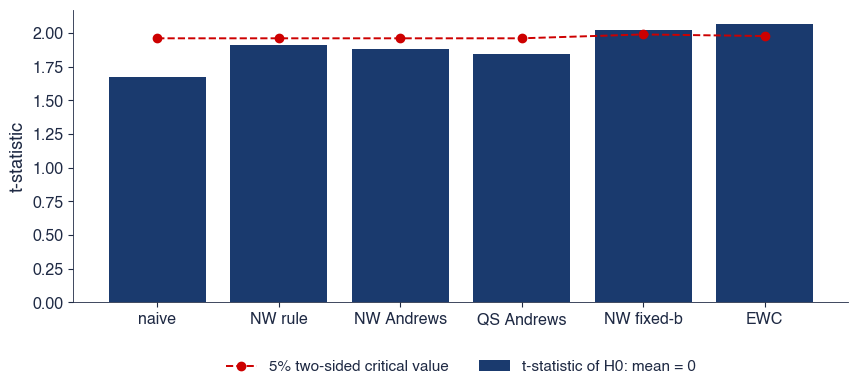

     naive      nw  andrews    llsw     ewc
se  0.0148  0.0129   0.0131  0.0122  0.0119
t   1.6698  1.9115   1.8818  2.0251  2.0693
cv  1.9600  1.9600   1.9600  1.9887  1.9768
mean = 0.0247  rho1 = -0.099


In [16]:
# Solution
b1 = b1_sp500(save_it=False, cvtab=cvtab)
print(pd.DataFrame({m: [b1[f'se_{m}'], b1[f't_{m}'], b1[f'cv_{m}']] for m in ('naive', 'nw', 'andrews', 'llsw', 'ewc')}, index=['se', 't', 'cv']).round(4))
print('mean =', round(b1['mean'], 4), ' rho1 =', round(b1['rho1'], 3))

**Interpretation of the result.** The first-order autocorrelation of daily index returns is negative, so the long-run variance is below the variance and the robust $t$-statistics are larger than the naive one; only the fixed-b and EWC tests reject, and barely.

## B2 [Proposed]: the mean growth of Romanian GDP

**Question.** How precisely do we know the average quarterly growth of Romanian real GDP since 2000? Model: B1.

1. Compute the mean, $\hat\rho_1$ and the 95% intervals with the five methods of B1 (`mean_inference`).
2. Add a stationary-bootstrap percentile interval with the Politis–White block length (4999 resamples).
3. Repeat the main estimates without the four quarters of 2020.
4. Interpretation: what matters more for this mean, dependence or the 2020 quarters?

**Report:** one mean, six intervals, one block length, one comparison, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: Monte Carlo of size under AR(1)

**Question.** With a sample as long as the Romanian GDP series, which test of a mean keeps its 5% size when the data are autocorrelated?

1. Simulate AR(1) paths ($\phi = 0, 0.5, 0.8$) with 200 burn-in values.
2. Test $H_0: \mu = 0$ at 5% with the naive test, NW rule of thumb, NW fixed-b and EWC.
3. Report the rejection rates and their Monte Carlo standard errors.
4. Interpretation: which test would you use for the mean of a series with $\hat\rho_1 = 0.5$ and $T \approx 100$?

**Report:** a 3 x 4 table of rejection rates, one Monte Carlo error, one sentence.

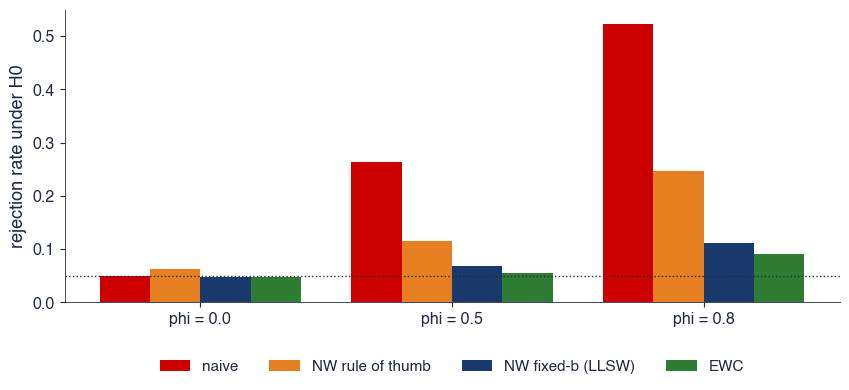

     naive     nw   llsw    ewc
0.0  0.050  0.062  0.048  0.047
0.5  0.263  0.114  0.069  0.054
0.8  0.524  0.248  0.112  0.091
Monte Carlo s.e. at 5%: 0.0034460121880225555


In [18]:
# Solution
b3 = b3_size(save_it=False, cvtab=cvtab)
print(pd.DataFrame(b3['res']).T.round(3))
print('Monte Carlo s.e. at 5%:', np.sqrt(0.05 * 0.95 / b3['reps']))

**Interpretation of the result.** At $\phi = 0.5$ only EWC and NW fixed-b stay close to 5%; the naive test and Newey–West with the rule of thumb over-reject, and the gap grows with $\phi$.

## B4 [Proposed]: Monte Carlo of size under GARCH(1,1)

**Question.** Does conditional heteroskedasticity alone distort a test on the mean of returns, and a test on the mean of squared returns? Model: B3.

1. Check that the unconditional variance is 1 and that the fourth moment exists.
2. Test $H_0: E r_t = 0$ and $H_0: E r_t^2 = 1$ with the four tests of B3 (`simulate_garch`, `size_table`).
3. Compute $\rho_1$ of $r_t^2$ from the GARCH formula.
4. Interpretation: why is the first test fine and the second one not?

**Report:** one moment condition, eight rejection rates, one autocorrelation, one sentence.

In [ ]:
# Your code here


## B5 [Solved]: replicating Granger and Newbold (1974)

**Question.** How often does a regression of one random walk on an independent one look significant, and can HAC standard errors fix it? Granger and Newbold (1974): $T = 50$, 100 regressions, $|t| > 2$ in 76 of 100 cases.

1. Replicate the design with 100, then 10000 replications.
2. Recompute the share of $|t| > 2$ with Newey–West and with NW fixed-b standard errors.
3. Repeat the regression in first differences.
4. Interpretation: is the published 76% consistent with your replication?

**Report:** four rejection shares, one Monte Carlo error, one sentence.

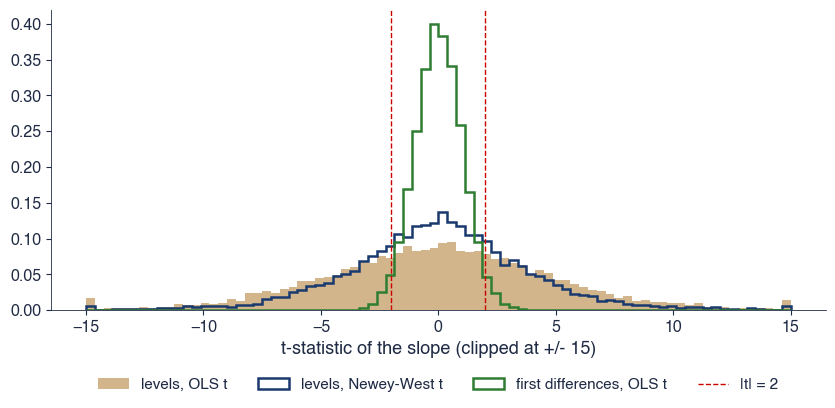

{'reps': 10000, 'T': 50, 'ols': 0.6587, 'nw': 0.5425, 'll': 0.4145, 'diff': 0.0506, 'first100': 0.68, 'cv_ll': 2.482124511747696, 'sd_t': 5.0614562090205535}
Monte Carlo s.e. with 100 replications: 0.047414587417797915


In [20]:
# Solution
b5 = b5_spurious(save_it=False, cvtab=cvtab)
print(b5)
print('Monte Carlo s.e. with 100 replications:', np.sqrt(b5['ols'] * (1 - b5['ols']) / 100))

**Interpretation of the result.** The long-run rejection rate is about two thirds; 76 of 100 lies about two Monte Carlo standard errors above it, so the result replicates in substance. HAC standard errors reduce but do not remove the problem; differencing restores the nominal size.

## B6 [Proposed]: block bootstrap of EUR/RON

**Question.** Has the leu depreciated significantly against the euro since 2005, on a daily mean basis? Model: B1.

1. Compute the mean, $\hat\rho_1$ and the Politis–White block lengths.
2. Compute bootstrap standard errors and 95% basic intervals with the i.i.d., moving-block, circular and stationary bootstrap (1999 resamples).
3. Convert the mean into an average annual depreciation.
4. Interpretation: why does the block bootstrap change so little here?

**Report:** one mean, two block lengths, four intervals, one annual rate, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: data snooping on the BET

**Question.** After adding momentum rules to the 50 moving-average rules of the lecture, does any rule beat buy-and-hold on the BET in 2013–2026? Model: A7, B1.

1. Write down the rule universe, the sample and the benchmark before computing.
2. Compute the excess return of each rule over buy-and-hold and the naive $t$ of the best rule.
3. Run the Reality Check with the stationary bootstrap (mean block 10, 999 resamples).
4. Interpretation: how would transaction costs of 0.1% per trade change the conclusion?

**Report:** a dated plan, one $t$-statistic, one Reality Check $p$-value, one sentence.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** Asked how to get correct standard errors for the mean of daily squared returns, an AI assistant wrote:

- (a) Newey–West standard errors are always larger than OLS standard errors;
- (b) for maximum robustness use $L = T - 1$ lags;
- (c) the wild bootstrap handles the autocorrelation of squared returns;
- (d) with $T = 6700$ observations the normal critical value 1.96 is always accurate;
- (e) the truncated kernel is better because it does not down-weight any lag;
- (f) the stationary bootstrap of Politis and Romano (1994) produces a stationary resampled series.

1. For each statement, say whether it is correct; if not, give the correct statement and the exercise of today that shows it.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
